In [1]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA를 사용할 수 없습니다.")

PyTorch 버전: 2.5.1+cu118
CUDA 사용 가능 여부: True
GPU 이름: NVIDIA GeForce RTX 4060 Ti


### 홈경기 vs 원정경기 승률 분석

In [2]:
pip install basketball-reference-scraper pandas matplotlib


Note: you may need to restart the kernel to use updated packages.


In [8]:
# 터미널 혹은 Jupyter cell(!)에서 실행
!pip install basketball-reference-web-scraper


In [12]:
from basketball_reference_web_scraper import client
import pandas as pd

# 1) 한 시즌만 샘플로 불러와서
sched_data = client.season_schedule(season_end_year=2025)
df = pd.DataFrame(sched_data)

# 2) 실제 컬럼명이 뭔지 출력해보기
print(df.columns.tolist())


['start_time', 'away_team', 'home_team', 'away_team_score', 'home_team_score']


In [3]:
# 0) 라이브러리 설치 (최초 1회만 실행)
# pip install basketball-reference-web-scraper pandas

from basketball_reference_web_scraper import client
import pandas as pd

# 1) 가져올 시즌 연도 리스트
years = [2024, 2025]

# 2) 시즌별 스케줄을 모아둘 list
dfs = []

for year in years:
    # 2-1) 시즌 스케줄 불러오기
    sched_data = client.season_schedule(season_end_year=year)
    df = pd.DataFrame(sched_data)
    
    # 2-2) 필요한 컬럼만 선택 & 이름 통일
    df_season = df[[
        'start_time', 
        'away_team', 'away_team_score', 
        'home_team', 'home_team_score'
    ]].rename(columns={
        'start_time':        'DATE',
        'away_team':         'VISITOR',
        'away_team_score':   'VISITOR_PTS',
        'home_team':         'HOME',
        'home_team_score':   'HOME_PTS'
    })
    
    # (선택) DATE 컬럼을 날짜만 쓰고 싶다면 아래 주석 해제
    # df_season['DATE'] = pd.to_datetime(df_season['DATE']).dt.date

    # 2-3) 시즌 라벨 추가 (예: "2023-24", "2024-25")
    df_season['season'] = f"{year-1}-{str(year)[-2:]}"

    dfs.append(df_season)

# 3) 두 시즌 합치기
df_all = pd.concat(dfs, ignore_index=True)

# 4) 홈/원정, 득·실점·승패·마진 계산
TEAM = "Golden State Warriors"
df_all['is_home']  = df_all['HOME'] == TEAM
df_all['team_pts'] = df_all.apply(lambda r: r['HOME_PTS'] if r['is_home'] else r['VISITOR_PTS'], axis=1)
df_all['opp_pts']  = df_all.apply(lambda r: r['VISITOR_PTS'] if r['is_home'] else r['HOME_PTS'], axis=1)
df_all['win']      = df_all['team_pts'] > df_all['opp_pts']
df_all['margin']   = df_all['team_pts'] - df_all['opp_pts']

# 5) 시즌별·홈/원정별 집계
summary = df_all.groupby(['season', 'is_home']).agg(
    games            = ('win', 'size'),
    wins             = ('win', 'sum'),
    win_pct          = ('win', 'mean'),
    avg_pts_for      = ('team_pts', 'mean'),
    avg_pts_against  = ('opp_pts', 'mean'),
    avg_margin       = ('margin', 'mean')
).rename(index={False: 'Away', True: 'Home'})

print(summary)


                 games  wins   win_pct  avg_pts_for  avg_pts_against  \
season  is_home                                                        
2023-24 Away      1319   597  0.452616   112.489007       114.806672   
2024-25 Away      1293   571  0.441609   112.810510       114.537420   

                 avg_margin  
season  is_home              
2023-24 Away      -2.317665  
2024-25 Away      -1.726911  


In [12]:
import pandas as pd
from basketball_reference_web_scraper.data import Team

# 0) df_all: 앞서 season_schedule → concat 으로 만드신 DataFrame
#    컬럼: ['season', 'DATE', 'VISITOR', 'VISITOR_PTS', 'HOME', 'HOME_PTS']

# 1) DATE를 datetime으로 변환하고, 날짜만 분리
df_all['DATE'] = pd.to_datetime(df_all['DATE'])
df_all['date'] = df_all['DATE'].dt.date

# 2) 정규 시즌 기간에 맞춰 필터
mask_2324 = (
    (df_all['season']=='2023-24') &
    df_all['date'].between(pd.to_datetime('2023-10-24').date(),
                           pd.to_datetime('2024-04-14').date())
)
mask_2425 = (
    (df_all['season']=='2024-25') &
    df_all['date'].between(pd.to_datetime('2024-10-24').date(),
                           pd.to_datetime('2025-04-16').date())
)
reg = df_all[mask_2324 | mask_2425]

# 3) GSW 경기만 추출
TEAM = Team.GOLDEN_STATE_WARRIORS
df_gsw = reg[(reg['HOME']==TEAM) | (reg['VISITOR']==TEAM)].copy()

# 4) Home/Away 레이블
df_gsw['Location'] = df_gsw['HOME'].map(lambda x: 'Home' if x==TEAM else 'Away')

# 5) 득점·실점·승패·마진 계산
df_gsw['team_pts'] = df_gsw.apply(
    lambda r: r['HOME_PTS'] if r['Location']=='Home' else r['VISITOR_PTS'], axis=1
)
df_gsw['opp_pts']  = df_gsw.apply(
    lambda r: r['VISITOR_PTS'] if r['Location']=='Home' else r['HOME_PTS'], axis=1
)
df_gsw['win']      = df_gsw['team_pts'] > df_gsw['opp_pts']
df_gsw['margin']   = df_gsw['team_pts'] - df_gsw['opp_pts']

# 6) 시즌·Location별 집계
summary_gsw = (
    df_gsw
    .groupby(['season','Location'])
    .agg(
        Games         = ('win',      'size'),
        Wins          = ('win',      'sum'),
        WinPct        = ('win',      'mean'),
        AvgPtsFor     = ('team_pts', 'mean'),
        AvgPtsAgainst = ('opp_pts',  'mean'),
        AvgMargin     = ('margin',   'mean')
    )
    .reset_index()
)
summary_gsw['WinPct'] *= 100  # 0~1 → 0~100%

print(summary_gsw)

summary_gsw.to_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/gsw_2024_25_홈경기_원정경기_승률.csv", index=False, encoding='utf-8-sig')


    season Location  Games  Wins     WinPct   AvgPtsFor  AvgPtsAgainst  \
0  2023-24     Away     41    25  60.975610  118.048780     113.512195   
1  2023-24     Home     41    21  51.219512  117.487805     116.804878   
2  2024-25     Away     41    24  58.536585  115.097561     110.707317   
3  2024-25     Home     42    25  59.523810  112.690476     110.404762   

   AvgMargin  
0   4.536585  
1   0.682927  
2   4.390244  
3   2.285714  


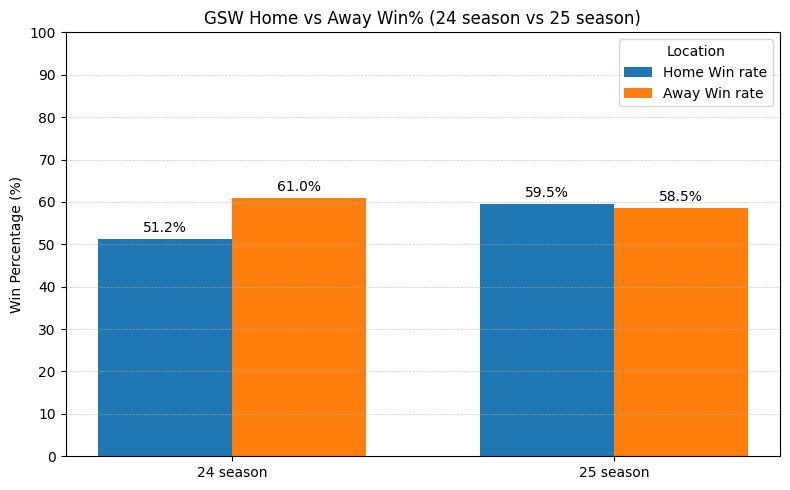

In [11]:
import matplotlib.pyplot as plt

# summary_gsw가 이미 준비되어 있고, WinPct 컬럼은 0~100 범위 값이라고 가정

# Pivot
pivot = summary_gsw.pivot(index='season', columns='Location', values='WinPct')

# x축 레이블 & 위치
x_labels = ['24 season', '25 season']
x = range(len(x_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))

bars_home = ax.bar(
    [i - width/2 for i in x],
    pivot['Home'],
    width,
    label='Home Win rate',
    color='tab:blue'
)
bars_away = ax.bar(
    [i + width/2 for i in x],
    pivot['Away'],
    width,
    label='Away Win rate',
    color='tab:orange'
)

# 막대 위 레이블
ax.bar_label(bars_home, fmt='%.1f%%', padding=3)
ax.bar_label(bars_away, fmt='%.1f%%', padding=3)

# 축 및 타이틀
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylabel('Win Percentage (%)')
ax.set_title('GSW Home vs Away Win% (24 season vs 25 season)')

# y축 0~100 고정, 10% 단위 눈금
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))

# 레전드 & 그리드
ax.legend(title='Location')
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()


시각화 분석
이 그래프는 2024 시즌과 2025 시즌의 골든 스테이트의 홈 경기, 원정 경기의 각 승률을 나타낸 그래프임. 
이 그래프에는 2024년 골든 스테이트가 정규 시즌에 진행했었던 홈경기 41경기 원정경기 41경기와 
2025년 골든 스테이트가 정규 시즌에 진행했었던 홈경기 42경기 원정경기 41경기 데이터가 포함되어 있음
2023~2024 시즌에는 홈경기 승률보다 원정경기의 승률이 9.8p 더 높았다는 것을 알 수 있음. 2024~2025 시즌에는 홈경기 승률이 다소 높은 결과를 보여줬음. 